<a href="https://colab.research.google.com/github/mr-zero-000/Statistical-Learning-e23034/blob/main/Assignment_1%20/%20Assignment_1_Q_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Given**

$$
T \sim \mathcal N(0,1), \quad P \sim \mathcal N(0,4), \quad T \perp P
$$

Joint density:
$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)
$$

Define:

* $X(t,p)=t$
* $Y(t,p)=(t,p)$



# **1. Probability space**

$$
\Omega=\mathbb{R}^2,\quad \mathcal F=\mathcal B(\mathbb{R}^2)
$$

$$
\mathbb P(A)=\int_A \frac{1}{4\pi}e^{-t^2/2 - p^2/8}\,dt\,dp
$$

So:
$$
(\Omega,\mathcal F,\mathbb P)
$$

# **2. \$\sigma\$-algebra generated by \$(X)\$**

Since $X(t,p)=t$,

$$
\sigma(X)=\{X^{-1}(B): B\in\mathcal B(\mathbb R)\}
$$

$$
X^{-1}(B)=B\times \mathbb R
$$

So:
$$
\sigma(X)=\{B\times \mathbb R: B\in\mathcal B(\mathbb R)\}
$$

# **3. \$\sigma\$-algebra generated by \$(Y)\$**

Since $Y$ is identity map:
$$
Y(t,p)=(t,p)
$$

So:
$$
\sigma(Y)=\mathcal B(\mathbb R^2)
$$

# **4. Show \$( \sigma(X)\subseteq \sigma(Y))\$**

Any set in $\sigma(X)$ is of form:
$$
B\times \mathbb R
$$
which is a Borel set in $\mathbb R^2$, hence in $\sigma(Y)$.

Thus:
$$
\sigma(X)\subset \sigma(Y)
$$

**Interpretation:**

* $X$: only temperature → less information
* $Y$: temperature + pressure → full system state → more information

# **5. Marginal density of \$(X)\$**

$$
X=T \sim \mathcal N(0,1)
$$

$$
f_X(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}
$$

# **6. Marginal density of \$(Y)\$**

Since independent:
$$
f_Y(t,p)=f_T(t)f_P(p)
$$

$$
f_Y(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)
$$

# **7. Probabilities**

### (i)

$$
P(X\le 0)=\frac12
$$

### (ii)

$$
P(X>1)=1-\Phi(1)\approx 0.1587
$$

### (iii)

$$
P(Y\in(-\infty,0]\times \mathbb R)=P(T\le0)=\frac12
$$

### (iv)

$$
P(Y\in[-1,1]\times[-2,2])=P(|T|\le1)P(|P|\le2)
$$

$$
= (2\Phi(1)-1)(2\Phi(1)-1)
$$

$$
= (2\Phi(1)-1)^2 \approx (0.6826)^2 \approx 0.466
$$

# **8. Conditional distribution \$(X|Y=(t,p))\$**

Since $X=t$ is fully determined:

$$
X|Y=(t,p)=t \quad \text{(degenerate)}
$$

So:
$$
P(X=t|Y=(t,p))=1
$$

# **9. Conditional distribution \$(Y|X=t)\$**

Fix $X=t$, then:
$$
Y=(t,P)
$$

So:

* first component fixed
* second is Gaussian

$$
Y|X=t \sim (t, \mathcal N(0,4))
$$

Density:
$$
f_{Y|X}(t',p|t)=\delta(t'-t)\cdot \frac{1}{\sqrt{8\pi}}e^{-p^2/8}
$$

# **10. Interpretation**

* Conditioning on $X$: only temperature known → pressure still random
* Conditioning on $Y$: full system known → no uncertainty left

# **11. Measurability**

Let:
$$
\pi_1(t,p)=t
$$

Then:
$$
X=\pi_1\circ Y
$$

Hence:

* composition of measurable functions ⇒ measurable
  $$
X \text{ is measurable w.r.t. } \sigma(Y)
$$

# **12. Visualization (Python)**

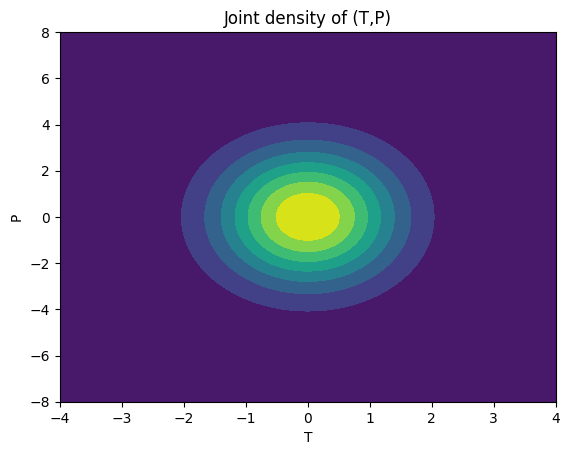

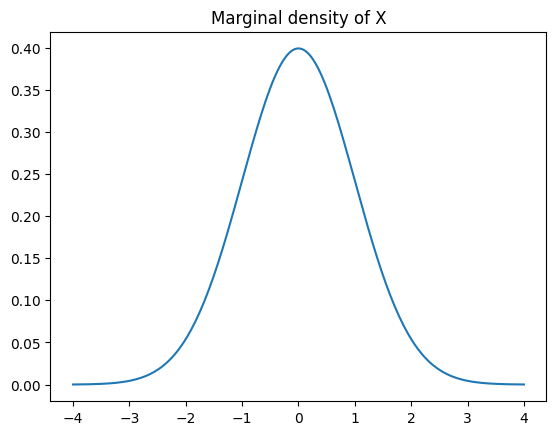

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# grid
t = np.linspace(-4,4,200)
p = np.linspace(-8,8,200)
T,P = np.meshgrid(t,p)

Z = (1/(4*np.pi))*np.exp(-T**2/2 - P**2/8)

plt.contourf(T,P,Z)
plt.title("Joint density of (T,P)")
plt.xlabel("T")
plt.ylabel("P")
plt.show()

# marginal of X
x = np.linspace(-4,4,200)
fx = norm.pdf(x)

plt.plot(x,fx)
plt.title("Marginal density of X")
plt.show()

# **12.1. Sigma-algebra Visualizations**

### Visualization of $\sigma(X) = \{B \times \mathbb{R} : B \in \mathcal{B}(\mathbb{R})\}$

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11418/2385008380.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Visualization of a Set in $\sigma(X)$ (Vertical Strip)')


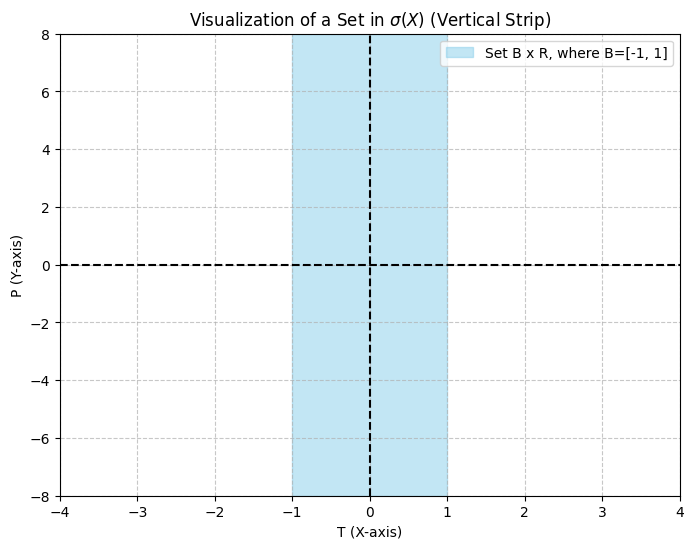

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range for t and p
t_vals = np.linspace(-4, 4, 200)
p_vals = np.linspace(-8, 8, 200)

# Define a set B for sigma(X) - a simple interval [t_min, t_max]
t_min = -1
t_max = 1

plt.figure(figsize=(8, 6))
plt.axvspan(t_min, t_max, color='skyblue', alpha=0.5, label=f'Set B x R, where B=[{t_min}, {t_max}]')
plt.plot(t_vals, np.zeros_like(t_vals), 'k--') # T-axis
plt.plot(np.zeros_like(p_vals), p_vals, 'k--') # P-axis
plt.xlim(-4, 4)
plt.ylim(-8, 8)
plt.xlabel('T (X-axis)')
plt.ylabel('P (Y-axis)')
plt.title('Visualization of a Set in $\sigma(X)$ (Vertical Strip)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Visualization of $\sigma(Y) = \mathcal{B}(\mathbb{R}^2)$

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11418/206577240.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Visualization of a Set in $\sigma(Y)$ (General Borel Set)')
/tmp/ipykernel_11418/206577240.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(T, P, Z_circle, levels=[0.5, 1.5], colors=['lightcoral'], alpha=0.6, label='General Borel Set (Disk)')


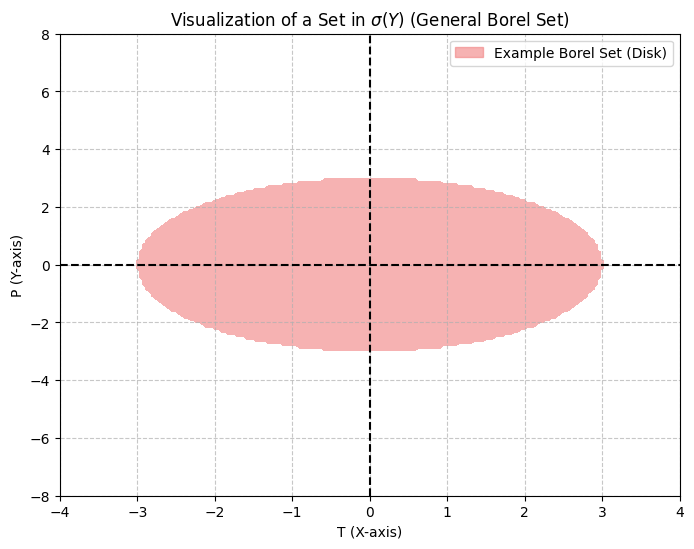

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range for t and p
t_vals = np.linspace(-4, 4, 200)
p_vals = np.linspace(-8, 8, 200)
T, P = np.meshgrid(t_vals, p_vals)

# Define a general Borel set in R^2 (e.g., a circular region)
center_t, center_p = 0, 0
radius = 3

# Create a mask for the circular region
Z_circle = (T - center_t)**2 + (P - center_p)**2 <= radius**2

plt.figure(figsize=(8, 6))
plt.contourf(T, P, Z_circle, levels=[0.5, 1.5], colors=['lightcoral'], alpha=0.6, label='General Borel Set (Disk)')
plt.plot(t_vals, np.zeros_like(t_vals), 'k--') # T-axis
plt.plot(np.zeros_like(p_vals), p_vals, 'k--') # P-axis
plt.xlim(-4, 4)
plt.ylim(-8, 8)
plt.xlabel('T (X-axis)')
plt.ylabel('P (Y-axis)')
plt.title('Visualization of a Set in $\sigma(Y)$ (General Borel Set)')
plt.grid(True, linestyle='--', alpha=0.7)

# Manually add legend entry since contourf doesn't directly support it for a single region
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='lightcoral', alpha=0.6, label='Example Borel Set (Disk)')
plt.legend(handles=[red_patch])

plt.show()

# **13. Differential entropy of \$(X)\$**

For $N(0,1)$:

$$
h(X)=\frac12\ln(2\pi e)
$$

# **14. Differential entropy of \$(Y)\$**

For independent Gaussians:

$$
h(Y)=h(T)+h(P)
$$

$$
h(T)=\frac12\ln(2\pi e),\quad h(P)=\frac12\ln(8\pi e)
$$

So:
$$
h(Y)=\ln(2\pi e)+\frac12\ln 4
$$

$$
h(Y)=\ln(2\pi e)+\ln 2
$$

$$
h(Y)=\ln(4\pi e)
$$

# **15. Conditional entropy \$(h(Y|X))\$**

$$
h(Y|X)=h(P|T)
$$

Independence ⇒:
$$
h(Y|X)=h(P)=\frac12\ln(8\pi e)
$$

**Interpretation:**
Uncertainty left is only pressure.

# **16. \$(h(X|Y))\$**

Since $X$ is deterministic given $Y$: $$
h(X|Y)=-\infty
$$ (important continuous phenomenon)

# **17. Key conceptual difference**

### Discrete case:

If $X=f(Y)$ then:
$$
H(X|Y)=0
$$

### Continuous case:

Even if deterministic:
$$
h(X|Y)=-\infty
$$

**Reason:**

* densities can involve Dirac delta
* entropy uses log-density → singularities